Generating thermal configurations...
Generated 400 thermal configs
Total training examples: 480

Training...
Epoch   1: Avg loss 0.068116
Epoch  10: Avg loss 0.002782
Epoch  20: Avg loss 0.001589
Epoch  30: Avg loss 0.001291
Epoch  40: Avg loss 0.001165
Epoch  50: Avg loss 0.001113
Epoch  60: Avg loss 0.001079
Epoch  70: Avg loss 0.001069
Epoch  80: Avg loss 0.001036
Epoch  90: Avg loss 0.001020
Epoch 100: Avg loss 0.001021
Training finished.

Running standard Metropolis chain...
Running kernel-accelerated chain...
Neural proposal acceptance rate: 94.580%

Energy observable:
  τ standard : 230.41
  τ kernel   : 126.72
  Improvement (energy): 1.82x

Magnetization² observable:
  τ standard : 236.88
  τ kernel   : 260.50
  Improvement (mag²)  : 0.91x



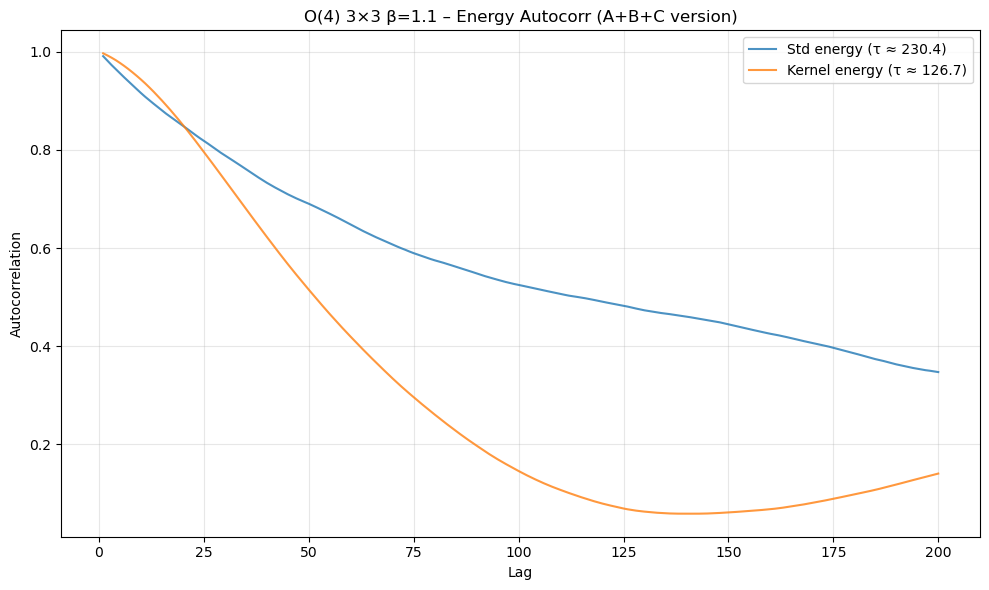

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────
# Model components (unchanged)
# ────────────────────────────────────────────────────────────────

class GoldstoneHyperHoloBlock(nn.Module):
    def __init__(self, dim=64, depth=5, alpha=1.7, slip_factor=0.15, ng_strength=0.1):
        super().__init__()
        self.depth = depth
        self.alpha = alpha
        self.proj = nn.Linear(dim, dim)
        self.slip_gen = nn.Linear(dim, dim)
        self.holo_proj = nn.Linear(dim * 2, dim * 4)
        self.inv_holo = nn.Linear(dim * 4, dim)
        self.ng_proj = nn.Linear(dim, dim)
        self.ng_strength = ng_strength
        self.slip_factor = slip_factor
        self.norm_h = nn.LayerNorm(dim)
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x, level=0, t_step=0.0):
        if level >= self.depth:
            return x

        slip = torch.tanh(self.slip_gen(x)) * self.slip_factor
        h = torch.relu(self.proj(x + slip))
        h = self.norm_h(h)

        h_child = self.forward(h, level + 1, t_step)

        concat = torch.cat([h, h_child], dim=-1)
        boundary = self.holo_proj(concat)
        resolved = self.inv_holo(boundary)
        fb = resolved * h

        vev_rand = torch.tanh(torch.randn_like(h.mean(dim=-1, keepdim=True)))
        vev = torch.norm(h, dim=-1, keepdim=True) * 0.005 * vev_rand
        h_broken = h + vev

        proj = self.ng_proj(h_broken)
        norm_hb_sq = h_broken.norm(dim=-1, keepdim=True)**2 + 1e-8
        dot = (proj * h_broken).sum(-1, keepdim=True) / norm_hb_sq
        goldstone = proj - dot * h_broken
        phase = torch.sin(t_step * 2.0 * np.pi + torch.randn_like(goldstone) * 0.2)

        h = h + self.ng_strength * goldstone * phase
        h = self.norm_h(h)

        out = x + fb + 0.05 * h_child
        mask_prob = max(0.1, 1.0 / ((level + 1) ** self.alpha))
        mask = (torch.rand_like(out) < mask_prob).float()
        out = out * mask
        out = self.norm_out(out)

        return out


class CoherenceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.fractal_core = GoldstoneHyperHoloBlock(hidden_dim)
        self.head = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, steps=1):
        h = self.embed(x)
        for t in range(steps):
            h = self.fractal_core(h, t_step=t / max(1, steps))
        return self.head(h)


# ────────────────────────────────────────────────────────────────
# O(4) helpers
# ────────────────────────────────────────────────────────────────

def o4_energy(spins, J=1.0):
    energy = 0.0
    N = spins.shape[0]
    for i in range(N):
        for j in range(N):
            energy += np.dot(spins[i, j], spins[i, (j + 1) % N])
            energy += np.dot(spins[i, j], spins[(i + 1) % N, j])
    return -J * energy


def get_observables(spins):
    """Return energy and |m|^2"""
    en = o4_energy(spins)
    mag = spins.mean(axis=(0, 1))
    mag2 = np.dot(mag, mag)
    return en, mag2


def metropolis_step(spins, beta):
    N = spins.shape[0]
    i, j = np.random.randint(0, N, 2)
    old_s = spins[i, j].copy()
    delta = np.random.randn(4) * 0.3
    new_s = old_s + delta
    norm = np.linalg.norm(new_s)
    if norm > 1e-8:
        new_s /= norm
    else:
        new_s = np.random.randn(4)
        new_s /= np.linalg.norm(new_s) + 1e-8

    dE = 0.0
    neigh = [(i, (j-1)%N), (i, (j+1)%N), ((i-1)%N, j), ((i+1)%N, j)]
    for ni, nj in neigh:
        dE += np.dot(new_s - old_s, spins[ni, nj])
    dE = -dE

    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        spins[i, j] = new_s
    return spins


def autocorrelation(ts, lag):
    if len(ts) <= lag:
        return 0.0
    mean = np.mean(ts)
    var = np.var(ts)
    if var < 1e-12:
        return 0.0
    cov = np.mean((ts[:-lag] - mean) * (ts[lag:] - mean))
    return cov / var


def integrated_autocorr_time(energies, max_lag=200, cutoff=0.05):
    if len(energies) < 20:
        return 1.0
    ac = [autocorrelation(energies, lag) for lag in range(1, min(max_lag, len(energies)) + 1)]
    for i, val in enumerate(ac):
        if val < cutoff:
            ac = ac[:i+1]
            break
    tau = 1 + 2 * np.sum(ac)
    return max(tau, 1.0)


# ────────────────────────────────────────────────────────────────
# Parameters — A + B applied here
# ────────────────────────────────────────────────────────────────

N = 3
input_dim = N * N * 4
beta = 1.1
mcmc_steps = 12000
burnin = 3000
n_thermal_configs = 400
n_random_fraction = 0.20

# ─── Option A ─── bolder proposal
mix_factor = 1.35
proposal_noise = 0.025

np.random.seed(46)


def initialize_o4_lattice(N):
    spins = np.random.randn(N, N, 4)
    norms = np.linalg.norm(spins, axis=-1, keepdims=True)
    spins /= np.maximum(norms, 1e-8)
    return spins


# ────────────────────────────────────────────────────────────────
# Generate thermal ensemble
# ────────────────────────────────────────────────────────────────

print("Generating thermal configurations...")
thermal_configs = []
spins_eq = initialize_o4_lattice(N)

for step in range(mcmc_steps + burnin):
    spins_eq = metropolis_step(spins_eq, beta)
    if step >= burnin and (step - burnin) % 12 == 0:
        thermal_configs.append(spins_eq.copy())
        if len(thermal_configs) >= n_thermal_configs:
            break

print(f"Generated {len(thermal_configs)} thermal configs")

n_random = int(n_thermal_configs * n_random_fraction)
random_configs = [initialize_o4_lattice(N) for _ in range(n_random)]

all_training_spins = thermal_configs + random_configs
np.random.shuffle(all_training_spins)

configs = [torch.tensor(s.flatten(), dtype=torch.float32).unsqueeze(0) for s in all_training_spins]
print(f"Total training examples: {len(configs)}\n")


# ────────────────────────────────────────────────────────────────
# Train — Option B: stronger noise
# ────────────────────────────────────────────────────────────────

model = CoherenceNet(input_dim=input_dim, hidden_dim=64)
optimizer = optim.Adam(model.parameters(), lr=0.0007)
criterion = nn.MSELoss()

n_epochs = 100
print_interval = 10

print("Training...")
for epoch in range(n_epochs):
    total_loss = 0.0
    for config in configs:
        # Option B: increased noise
        noisy_target = config + torch.randn_like(config) * 0.09
        noisy_target = noisy_target / (torch.norm(noisy_target, dim=-1, keepdim=True) + 1e-8)

        pred = model(config, steps=1)
        loss = criterion(pred, noisy_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(configs)
    if (epoch + 1) % print_interval == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}: Avg loss {avg_loss:.6f}")

print("Training finished.\n")


# ────────────────────────────────────────────────────────────────
# Robust neural proposal
# ────────────────────────────────────────────────────────────────

def neural_proposal(spins, model, beta, fallback_step=metropolis_step):
    try:
        flat = torch.tensor(spins.flatten(), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            pred_flat = model(flat, steps=1).numpy().flatten()

        pred = pred_flat.reshape(N, N, 4)
        pred_norm = np.linalg.norm(pred, axis=-1, keepdims=True)
        pred /= np.maximum(pred_norm, 1e-8)

        delta = pred - spins
        proposed = spins + mix_factor * delta
        proposed += np.random.randn(*proposed.shape) * proposal_noise

        prop_norm = np.linalg.norm(proposed, axis=-1, keepdims=True)
        proposed /= np.maximum(prop_norm, 1e-8)

        bad = np.any(prop_norm.squeeze(-1) < 1e-6)
        if bad:
            proposed = initialize_o4_lattice(N)

        dE = o4_energy(proposed) - o4_energy(spins)

        if dE < 0:
            accept = True
        else:
            arg = -beta * dE
            if arg < -700:
                accept = False
            elif arg > 700:
                accept = True
            else:
                accept = np.random.rand() < np.exp(arg)

        return proposed.copy() if accept else spins.copy(), accept

    except Exception as e:
        print(f"Proposal failed: {e} → fallback to local step")
        new_spins = fallback_step(spins.copy(), beta)
        return new_spins, False


# ────────────────────────────────────────────────────────────────
# Run chains — collecting energy + mag²
# ────────────────────────────────────────────────────────────────

print("Running standard Metropolis chain...")
np.random.seed(44)
spins_std = initialize_o4_lattice(N)
energy_std = []
mag2_std = []

for step in range(mcmc_steps + burnin):
    spins_std = metropolis_step(spins_std, beta)
    if step >= burnin:
        en, m2 = get_observables(spins_std)
        energy_std.append(en)
        mag2_std.append(m2)

print("Running kernel-accelerated chain...")
np.random.seed(45)
spins_neural = initialize_o4_lattice(N)
energy_neural = []
mag2_neural = []
accepts = 0
total_prop = 0

for step in range(mcmc_steps + burnin):
    proposed, accepted = neural_proposal(spins_neural, model, beta)
    spins_neural = proposed
    total_prop += 1
    if accepted:
        accepts += 1
    if step >= burnin:
        en, m2 = get_observables(spins_neural)
        energy_neural.append(en)
        mag2_neural.append(m2)

accept_rate = accepts / total_prop if total_prop > 0 else 0
print(f"Neural proposal acceptance rate: {accept_rate:.3%}\n")


# ────────────────────────────────────────────────────────────────
# Autocorrelation & tau — for both observables
# ────────────────────────────────────────────────────────────────

tau_en_std   = integrated_autocorr_time(energy_std)
tau_en_neural = integrated_autocorr_time(energy_neural)
tau_mag_std   = integrated_autocorr_time(mag2_std)
tau_mag_neural = integrated_autocorr_time(mag2_neural)

print("Energy observable:")
print(f"  τ standard : {tau_en_std:.2f}")
print(f"  τ kernel   : {tau_en_neural:.2f}")
print(f"  Improvement (energy): {tau_en_std / tau_en_neural:.2f}x\n")

print("Magnetization² observable:")
print(f"  τ standard : {tau_mag_std:.2f}")
print(f"  τ kernel   : {tau_mag_neural:.2f}")
print(f"  Improvement (mag²)  : {tau_mag_std / tau_mag_neural:.2f}x\n")


# ────────────────────────────────────────────────────────────────
# Plot — energy autocorrelation
# ────────────────────────────────────────────────────────────────

max_lag_plot = 200
ac_en_std   = [autocorrelation(energy_std,   lag) for lag in range(1, min(max_lag_plot, len(energy_std))+1)]
ac_en_neural = [autocorrelation(energy_neural, lag) for lag in range(1, min(max_lag_plot, len(energy_neural))+1)]

lags = np.arange(1, len(ac_en_std) + 1)
plt.figure(figsize=(10, 6))
plt.plot(lags, ac_en_std,   label=f'Std energy (τ ≈ {tau_en_std:.1f})',   alpha=0.8)
plt.plot(lags, ac_en_neural, label=f'Kernel energy (τ ≈ {tau_en_neural:.1f})', alpha=0.8)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('O(4) 3×3 β=1.1 – Energy Autocorr (A+B+C version)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Autocor12.png")
plt.show()